<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/Repeated_kfold__Key_gene_selection_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import subprocess
subprocess.run(["pip", "install", "-q",
                "xgboost", "shap", "scikit-learn",
                "pandas", "numpy", "matplotlib",
                "seaborn"], check=True)
print("✅ All packages installed!")

✅ All packages installed!


In [25]:
DESCRIP_FILE  = 'matched_ko_full_rows.csv'
METADATA_FILE = 'metadata.tsv'

print('✅ Files ready:')
print(f'   descrip  → {DESCRIP_FILE}')
print(f'   metadata → {METADATA_FILE}')

✅ Files ready:
   descrip  → matched_ko_full_rows.csv
   metadata → metadata.tsv


In [53]:
TARGET_COLUMN  = "Groups"
CLASS_POSITIVE = "T2DM"
CLASS_NEGATIVE = "Control"

TOP_N        = 15
N_CV_FOLDS   = 5
N_REPEATS    = 10
RANDOM_STATE = 42
TEST_SIZE    = 0.2

print("✅ Configuration set:")
print(f"  Descrip file  : {DESCRIP_FILE}")
print(f"  Metadata file : {METADATA_FILE}")
print(f"  Target column : '{TARGET_COLUMN}'  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Top N genes   : {TOP_N}")
print(f"  Test size     : {TEST_SIZE}")
print(f"  CV folds      : {N_CV_FOLDS}")
print(f"  CV repeats    : {N_REPEATS}")
print(f"  Total CV evals: {N_CV_FOLDS * N_REPEATS}")

✅ Configuration set:
  Descrip file  : matched_ko_full_rows.csv
  Metadata file : metadata.tsv
  Target column : 'Groups'  (T2DM vs Control)
  Top N genes   : 15
  Test size     : 0.2
  CV folds      : 5
  CV repeats    : 10
  Total CV evals: 50


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, cross_val_predict,
                                     train_test_split, RandomizedSearchCV)
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (ConfusionMatrixDisplay, classification_report,
                                     roc_auc_score)
from xgboost import XGBClassifier
import shap

print("✅ Libraries imported!")

✅ Libraries imported!


In [55]:
raw = pd.read_csv(DESCRIP_FILE, index_col=0, comment='#')

desc_col = next((c for c in raw.columns if 'desc' in c.lower()), None)

if desc_col:
    annot_raw  = raw[[desc_col]].copy()
    gene_table = raw.drop(columns=[desc_col])
else:
    annot_raw  = pd.DataFrame(index=raw.index)
    gene_table = raw.copy()

# KO rows, sample columns → transpose
gene_table = gene_table.T
gene_table = gene_table.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Gene table : {gene_table.shape[0]} samples × {gene_table.shape[1]} KO genes")
print(f"  Sample IDs : {gene_table.index[:3].tolist()}")
print(f"  KO IDs     : {gene_table.columns[:3].tolist()}")

Gene table : 116 samples × 40 KO genes
  Sample IDs : ['SRR36668761', 'SRR36668762', 'SRR36668763']
  KO IDs     : ['K00255', 'K03383', 'K03537']


In [56]:
def split_desc(val):
    val = str(val)
    if ';' in val:
        gene_part, def_part = val.split(';', 1)
        return gene_part.strip().split(',')[0].strip(), def_part.strip()
    return val.strip(), val.strip()

if desc_col:
    annot_raw[['gene_name', 'definition']] = annot_raw[desc_col].apply(
        lambda x: pd.Series(split_desc(x))
    )
    annot_df = annot_raw[['gene_name', 'definition']].copy()
    annot_df.index.name = 'KO'
else:
    annot_df = pd.DataFrame(index=gene_table.columns)
    annot_df['gene_name']  = 'Unknown'
    annot_df['definition'] = 'No annotation'

print(f"✅ {len(annot_df)} KO annotations parsed")
print(annot_df.head(5).to_string())

✅ 40 KO annotations parsed
       gene_name                                                                          definition
KO                                                                                                  
K00255     ACADL                                      long-chain-acyl-CoA dehydrogenase [EC:1.3.8.8]
K03383      atzD                                          cyanuric acid amidohydrolase [EC:3.5.2.15]
K03537      POP5                               ribonuclease P/MRP protein subunit POP5 [EC:3.1.26.5]
K04066      priA  primosomal protein N' (replication factor Y) (superfamily II helicase)[EC:5.6.2.4]
K05575      ndhD                               NAD(P)H-quinone oxidoreductase subunit 4 [EC:1.6.5.3]


In [58]:
sep = '\t' if METADATA_FILE.endswith('.tsv') else ','
metadata = pd.read_csv(METADATA_FILE, sep=sep, index_col=0)
metadata.index = metadata.index.astype(str)
if str(metadata.index[0]).startswith('#'):
    metadata = metadata.iloc[1:]

gene_table.index = gene_table.index.astype(str)

common = gene_table.index.intersection(metadata.index)
print(f"Samples in gene table : {len(gene_table)}")
print(f"Samples in metadata   : {len(metadata)}")
print(f"Common samples        : {len(common)}")

if len(common) == 0:
    raise ValueError("❌ No common samples! Check sample ID formatting.")

gene_table = gene_table.loc[common]
metadata   = metadata.loc[common].dropna(subset=[TARGET_COLUMN])
gene_table = gene_table.loc[metadata.index]
print(f"Samples after dropping missing target: {len(gene_table)}")

X             = gene_table.values
feature_names = gene_table.columns.tolist()
le            = LabelEncoder()
y             = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes       = le.classes_
n_classes     = len(classes)

print(f"\nTarget classes : {list(classes)}")
print(f"Class counts   : {dict(zip(classes, np.bincount(y)))}")

Samples in gene table : 116
Samples in metadata   : 116
Common samples        : 116
Samples after dropping missing target: 116

Target classes : ['Control', 'T2DM']
Class counts   : {'Control': np.int64(38), 'T2DM': np.int64(78)}


In [59]:
# Normalise: relative abundance → log(CPM + 1)
gene_table = gene_table.div(gene_table.sum(axis=1), axis=0)
gene_table = np.log1p(gene_table * 1e6)

# Zero-variance filter
gene_table = gene_table.loc[:, gene_table.var() > 0]
print(f"Genes after zero-variance filter: {gene_table.shape[1]}")

X             = gene_table.values
feature_names = gene_table.columns.tolist()
le            = LabelEncoder()
y             = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes       = le.classes_
n_classes     = len(classes)

print(f"\nFinal feature matrix : {X.shape}")
print(f"Target classes       : {list(classes)}")
print(f"Class counts         : {dict(zip(classes, np.bincount(y)))}")

Genes after zero-variance filter: 40

Final feature matrix : (116, 40)
Target classes       : ['Control', 'T2DM']
Class counts         : {'Control': np.int64(38), 'T2DM': np.int64(78)}


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE
)

print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Train class counts : {dict(zip(classes, np.bincount(y_train)))}")
print(f"Test class counts  : {dict(zip(classes, np.bincount(y_test)))}")

Train samples : 92
Test samples  : 24
Train class counts : {'Control': np.int64(30), 'T2DM': np.int64(62)}
Test class counts  : {'Control': np.int64(8), 'T2DM': np.int64(16)}


In [61]:
param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

base_model = XGBClassifier(
    eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)

# RepeatedStratifiedKFold: 3 folds × 5 repeats = 15 evaluations
cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    base_model,
    param_distributions = param_dist,
    n_iter       = 30,
    scoring      = "roc_auc_ovr" if n_classes > 2 else "roc_auc",
    cv           = cv_inner,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbose      = 1,
)
search.fit(X_train, y_train)

best_params = search.best_params_
print(f"\n✅ Best parameters   : {best_params}")
print(f"   Best CV AUC (inner): {search.best_score_:.4f}")

Fitting 15 folds for each of 30 candidates, totalling 450 fits

✅ Best parameters   : {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
   Best CV AUC (inner): 0.9467


In [62]:
model = XGBClassifier(
    **best_params,
    eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)

# RepeatedStratifiedKFold: 5 folds × 10 repeats = 50 evaluations
cv_outer  = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=N_REPEATS,
                                     random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv_outer,
                             scoring="roc_auc_ovr" if n_classes > 2 else "roc_auc")

print(f"Repeated Stratified K-Fold CV ({N_CV_FOLDS} folds × {N_REPEATS} repeats = {N_CV_FOLDS*N_REPEATS} evaluations):")
print(f"  Mean AUC : {cv_scores.mean():.4f}")
print(f"  Std AUC  : {cv_scores.std():.4f}")
print(f"  Min AUC  : {cv_scores.min():.4f}")
print(f"  Max AUC  : {cv_scores.max():.4f}")

model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)
test_auc   = roc_auc_score(y_test,
                            test_proba[:, 1] if n_classes == 2 else test_proba,
                            multi_class="ovr")
print(f"\nHeld-out Test AUC : {test_auc:.4f}")
print("✅ Final model trained and evaluated")

Repeated Stratified K-Fold CV (5 folds × 10 repeats = 50 evaluations):
  Mean AUC : 0.9502
  Std AUC  : 0.0450
  Min AUC  : 0.7847
  Max AUC  : 1.0000

Held-out Test AUC : 1.0000
✅ Final model trained and evaluated


In [63]:
importances   = model.feature_importances_
importance_df = pd.DataFrame({
    "KO"        : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df['gene_name']  = importance_df['KO'].map(annot_df['gene_name']).fillna('Unknown')
importance_df['definition'] = importance_df['KO'].map(annot_df['definition']).fillna('No annotation')
importance_df['Label'] = importance_df.apply(
    lambda r: r['gene_name'] if r['gene_name'] not in ['', 'Unknown'] else r['KO'], axis=1
)

print("✅ Gene importance computed & annotations mapped")
print(f"\nTop 10 genes by XGBoost gain:")
print(importance_df[['KO','gene_name','Importance','definition']].head(10).to_string(index=False))

✅ Gene importance computed & annotations mapped

Top 10 genes by XGBoost gain:
    KO gene_name  Importance                                                                         definition
K06351      kipI    0.191561                                                                  inhibitor of KinA
K06348      kapD    0.174409                                                         sporulation inhibitor KapD
K17865      croR    0.085413                                     3-hydroxybutyryl-CoA dehydratase [EC:4.2.1.55]
K08723      yjjG    0.062972                                            pyrimidine 5'-nucleotidase [EC:3.1.3.-]
K06045       shc    0.062312        squalene-hopene/tetraprenyl-beta-curcumene cyclase [EC:5.4.99.17 4.2.1.129]
K03383      atzD    0.061845                                         cyanuric acid amidohydrolase [EC:3.5.2.15]
K06937    K06937    0.054008                 7,8-dihydro-6-hydroxymethylpterin dimethyltransferase [EC:2.1.1.-]
K17246      chiG    0.053

In [64]:
print("Computing SHAP values on test set ...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "KO"       : feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).reset_index(drop=True)

label_map = importance_df.set_index("KO")["Label"]
shap_df["Label"]      = shap_df["KO"].map(label_map).fillna(shap_df["KO"])
shap_df["gene_name"]  = shap_df["KO"].map(annot_df["gene_name"]).fillna("Unknown")
shap_df["definition"] = shap_df["KO"].map(annot_df["definition"]).fillna("No annotation")

print("✅ SHAP values computed on held-out test set!")
print(f"\nTop 10 genes by SHAP:")
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))

Computing SHAP values on test set ...
✅ SHAP values computed on held-out test set!

Top 10 genes by SHAP:
    KO gene_name  Mean_SHAP                                                                    definition
K06348      kapD   0.336265                                                    sporulation inhibitor KapD
K06937    K06937   0.235656            7,8-dihydro-6-hydroxymethylpterin dimethyltransferase [EC:2.1.1.-]
K06045       shc   0.174884   squalene-hopene/tetraprenyl-beta-curcumene cyclase [EC:5.4.99.17 4.2.1.129]
K06351      kipI   0.147405                                                             inhibitor of KinA
K17246      chiG   0.055040                         putative chitobiose transport system permease protein
K07710      atoS   0.042226 two-component system, NtrC family, sensor histidine kinase AtoS [EC:2.7.13.3]
K08723      yjjG   0.040238                                       pyrimidine 5'-nucleotidase [EC:3.1.3.-]
K03537      POP5   0.034533                   

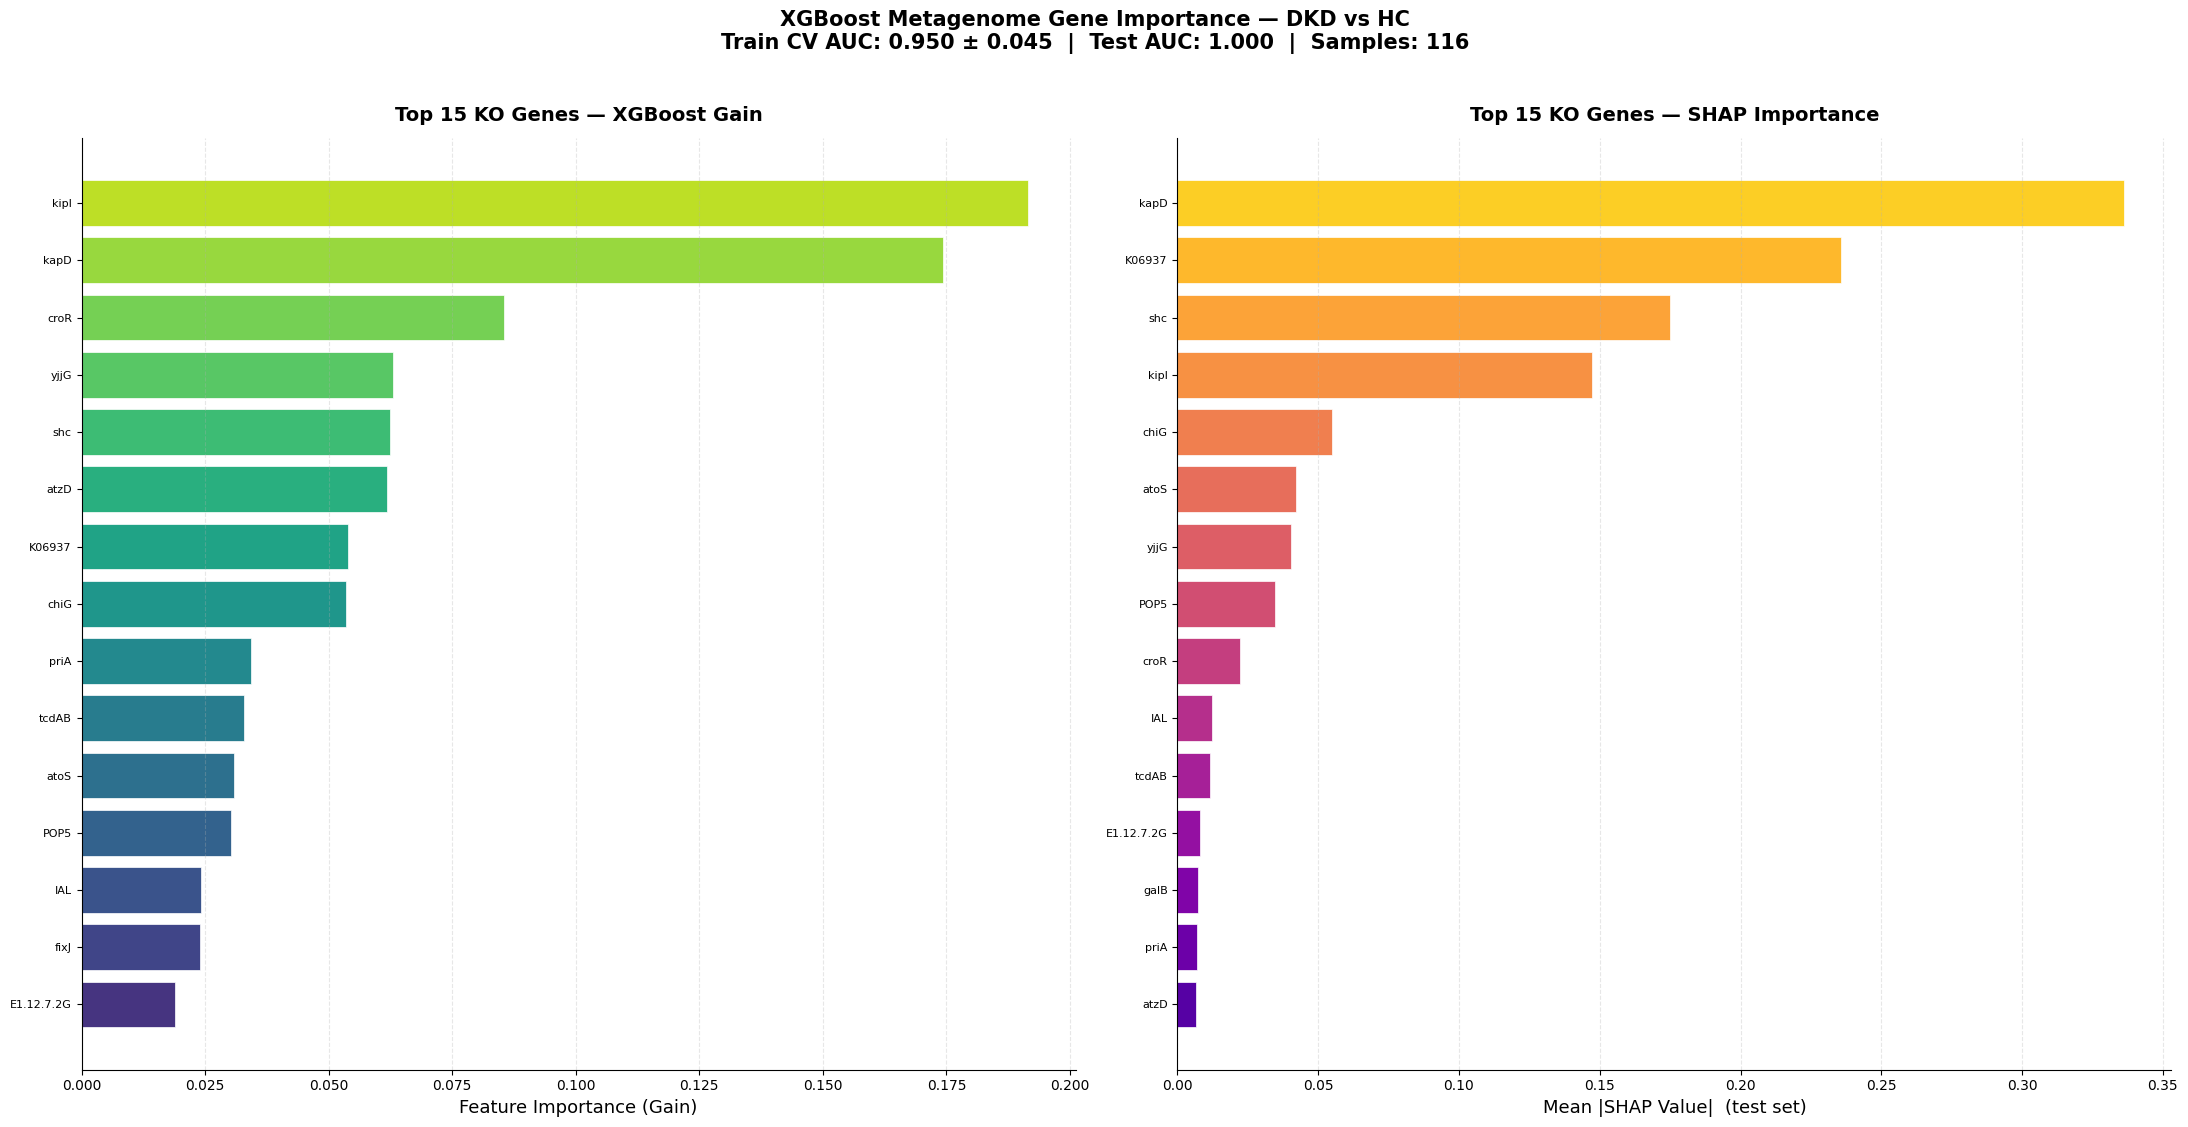

✅ Saved: importance_plots.svg


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

top_imp = importance_df.head(TOP_N).sort_values("Importance")
cmap_a  = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_imp)))
axes[0].barh(top_imp["Label"], top_imp["Importance"],
             color=cmap_a, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Feature Importance (Gain)", fontsize=13)
axes[0].set_title(f"Top {TOP_N} KO Genes — XGBoost Gain",
                  fontsize=14, fontweight="bold", pad=12)
axes[0].tick_params(axis="y", labelsize=8)
axes[0].grid(axis="x", alpha=0.3, linestyle="--")
axes[0].spines[["top","right"]].set_visible(False)

top_shap = shap_df.head(TOP_N).sort_values("Mean_SHAP")
cmap_b   = plt.cm.plasma(np.linspace(0.15, 0.9, len(top_shap)))
axes[1].barh(top_shap["Label"], top_shap["Mean_SHAP"],
             color=cmap_b, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean |SHAP Value|  (test set)", fontsize=13)
axes[1].set_title(f"Top {TOP_N} KO Genes — SHAP Importance",
                  fontsize=14, fontweight="bold", pad=12)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].grid(axis="x", alpha=0.3, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(
    f"XGBoost Metagenome Gene Importance — DKD vs HC\n"
    f"Train CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  "
    f"Test AUC: {test_auc:.3f}  |  Samples: {len(X)}",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("importance_plots.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: importance_plots.svg")

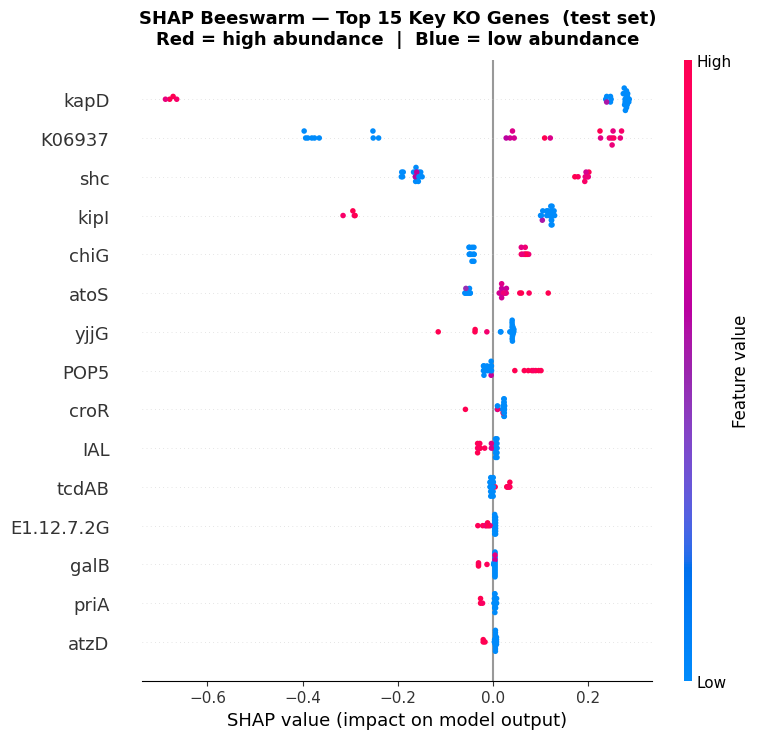

✅ Saved: shap_beeswarm.svg


In [66]:
top_fids   = shap_df.head(TOP_N)["KO"].tolist()
top_idx    = [feature_names.index(f) for f in top_fids if f in feature_names]
top_labels = [shap_df.loc[shap_df["KO"] == feature_names[i], "Label"].values[0]
               for i in top_idx]

shap_vals_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
base_val       = (explainer.expected_value[0]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

explanation = shap.Explanation(
    values        = shap_vals_plot[:, top_idx],
    base_values   = base_val,
    data          = X_test[:, top_idx],
    feature_names = top_labels
)

plt.figure(figsize=(12, 11))
shap.plots.beeswarm(explanation, show=False, max_display=TOP_N)
plt.title(f"SHAP Beeswarm — Top {TOP_N} Key KO Genes  (test set)\n"
          f"Red = high abundance  |  Blue = low abundance",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.svg")

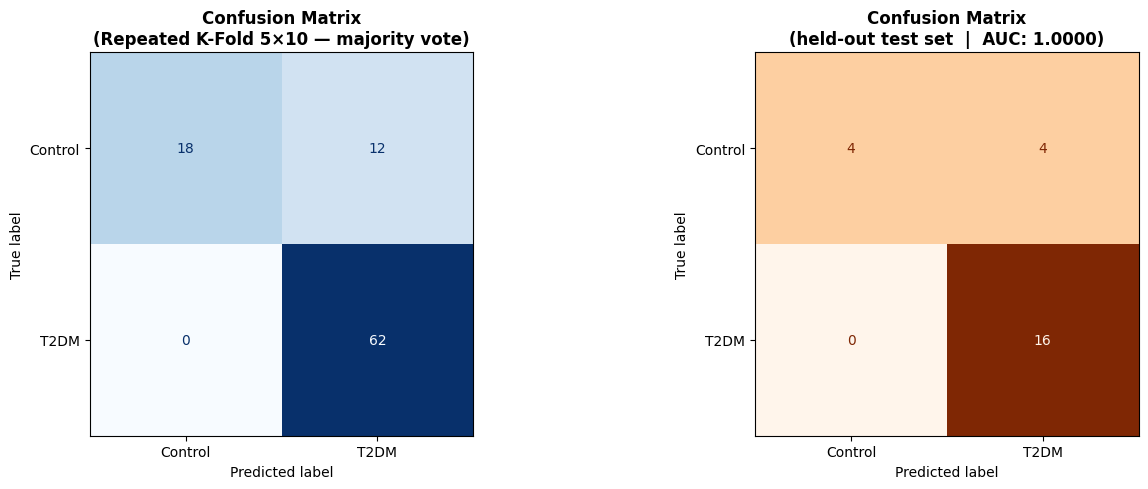


Classification Report — Repeated K-Fold (train):
              precision    recall  f1-score   support

     Control       1.00      0.60      0.75        30
        T2DM       0.84      1.00      0.91        62

    accuracy                           0.87        92
   macro avg       0.92      0.80      0.83        92
weighted avg       0.89      0.87      0.86        92


Classification Report — Held-out Test Set:
              precision    recall  f1-score   support

     Control       1.00      0.50      0.67         8
        T2DM       0.80      1.00      0.89        16

    accuracy                           0.83        24
   macro avg       0.90      0.75      0.78        24
weighted avg       0.87      0.83      0.81        24

✅ Saved: confusion_matrix.svg


In [67]:
from collections import defaultdict
from scipy import stats

# Collect predictions for each sample across all repeats
sample_preds = defaultdict(list)

rskf = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=N_REPEATS,
                                random_state=RANDOM_STATE)

for train_idx, test_idx in rskf.split(X_train, y_train):
    fold_model = XGBClassifier(
        **best_params,
        eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    fold_model.fit(X_train[train_idx], y_train[train_idx])
    fold_preds = fold_model.predict(X_train[test_idx])

    for idx, pred in zip(test_idx, fold_preds):
        sample_preds[idx].append(pred)

# Majority vote across all repeats for each sample
y_pred_rskf = np.array([
    stats.mode(sample_preds[i], keepdims=True).mode[0]
    for i in range(len(X_train))
])

# ── Plot ───────────────────────────────────────────────────────────
y_pred_test = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_rskf,
    display_labels = classes,
    cmap           = "Blues",
    ax             = axes[0],
    colorbar       = False
)
axes[0].set_title(f"Confusion Matrix\n(Repeated K-Fold {N_CV_FOLDS}×{N_REPEATS} — majority vote)",
                   fontsize=12, fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels = classes,
    cmap           = "Oranges",
    ax             = axes[1],
    colorbar       = False
)
axes[1].set_title(f"Confusion Matrix\n(held-out test set  |  AUC: {test_auc:.4f})",
                   fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.svg", dpi=300, bbox_inches="tight")
plt.show()

print("\nClassification Report — Repeated K-Fold (train):")
print(classification_report(y_train, y_pred_rskf, target_names=classes))
print("\nClassification Report — Held-out Test Set:")
print(classification_report(y_test, y_pred_test, target_names=classes))
print("✅ Saved: confusion_matrix.svg")

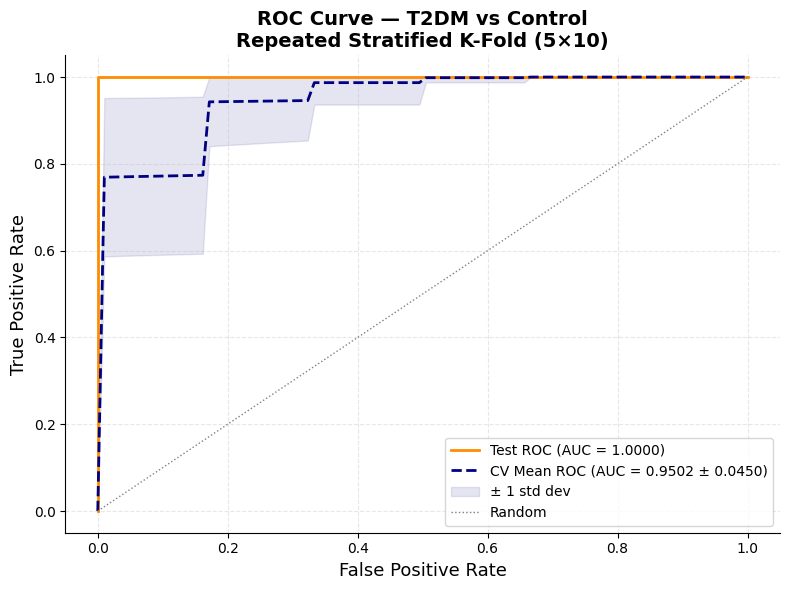

✅ Saved: roc_curve.svg


In [68]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, ax = plt.subplots(figsize=(8, 6))

# ── Test set ROC ───────────────────────────────────────────────────
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'Test ROC (AUC = {roc_auc:.4f})')
else:
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i],
                                 model.predict_proba(X_test)[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.4f})')

# ── CV ROC (mean ± std across repeated folds) ─────────────────────
tprs, aucs = [], []
mean_fpr    = np.linspace(0, 1, 100)

rskf = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=N_REPEATS,
                                random_state=RANDOM_STATE)

for train_idx, test_idx in rskf.split(X_train, y_train):
    fold_model = XGBClassifier(
        **best_params,
        eval_metric  = "mlogloss" if n_classes > 2 else "logloss",
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    fold_model.fit(X_train[train_idx], y_train[train_idx])
    fold_proba = fold_model.predict_proba(X_train[test_idx])

    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_train[test_idx], fold_proba[:, 1])
    else:
        fpr, tpr, _ = roc_curve(
            label_binarize(y_train[test_idx], classes=range(n_classes)).ravel(),
            fold_proba.ravel()
        )

    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))

mean_tpr      = np.mean(tprs, axis=0)
mean_tpr[-1]  = 1.0
mean_auc      = np.mean(aucs)
std_auc       = np.std(aucs)
std_tpr       = np.std(tprs, axis=0)
tprs_upper    = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower    = np.maximum(mean_tpr - std_tpr, 0)

ax.plot(mean_fpr, mean_tpr, color='navy', lw=2, linestyle='--',
        label=f'CV Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})')
ax.fill_between(mean_fpr, tprs_lower, tprs_upper,
                color='navy', alpha=0.1, label='± 1 std dev')

# ── Diagonal reference line ────────────────────────────────────────
ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':', label='Random')

ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title(f"ROC Curve — {CLASS_POSITIVE} vs {CLASS_NEGATIVE}\n"
             f"Repeated Stratified K-Fold ({N_CV_FOLDS}×{N_REPEATS})",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curve.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: roc_curve.svg")

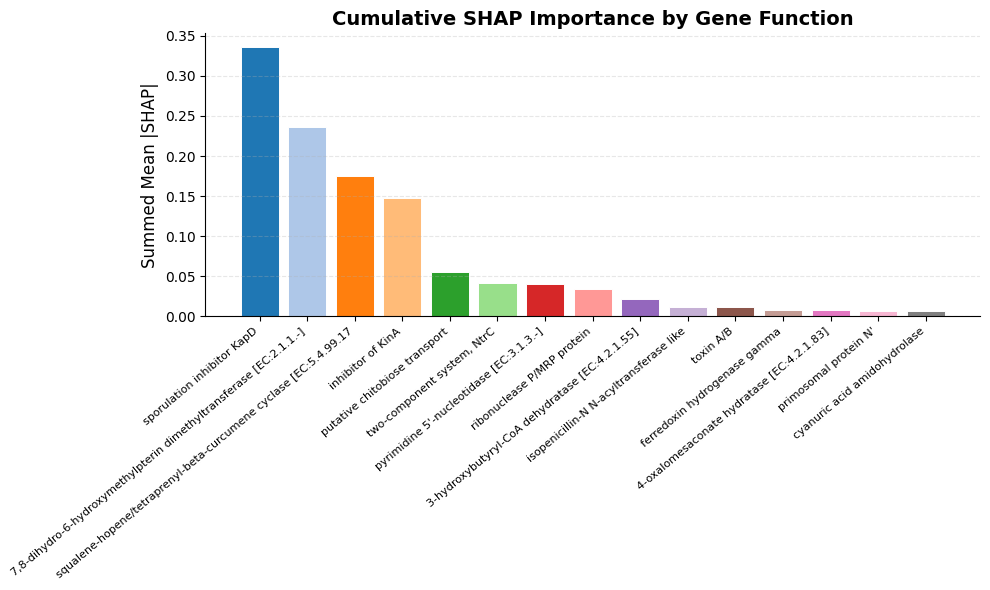

✅ Saved: gene_function_importance.svg


In [69]:
shap_df["Category"] = shap_df["definition"].apply(
    lambda x: " ".join(str(x).split()[:3]) if x not in ["No annotation", "Unknown"] else "Unclassified"
)

cat_imp = (
    shap_df[shap_df["Category"] != "Unclassified"]
    .groupby("Category")["Mean_SHAP"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

if len(cat_imp) > 0:
    palette = sns.color_palette("tab20", len(cat_imp))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(cat_imp)), cat_imp["Mean_SHAP"],
           color=palette, edgecolor="white", linewidth=0.7)
    ax.set_xticks(range(len(cat_imp)))
    ax.set_xticklabels(cat_imp["Category"], rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Summed Mean |SHAP|", fontsize=12)
    ax.set_title("Cumulative SHAP Importance by Gene Function",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("gene_function_importance.svg", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ Saved: gene_function_importance.svg")
else:
    print("⚠️  Function plot skipped — no annotations available.")

In [70]:
from google.colab import files as colab_files

importance_df.to_csv("xgboost_gene_importance.csv", index=False)
shap_df.to_csv("xgboost_shap_gene_importance.csv", index=False)
print("✅ CSVs saved")

print("\n" + "═"*55)
print("  ANALYSIS COMPLETE — SUMMARY")
print("═"*55)
print(f"  Total samples     : {len(X)}")
print(f"  Train samples     : {len(X_train)}")
print(f"  Test samples      : {len(X_test)}")
print(f"  KO genes used     : {len(feature_names)}")
print(f"  Target variable   : {TARGET_COLUMN}  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Best params       : {best_params}")
print(f"  Train CV AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Test AUC          : {test_auc:.4f}")
print(f"\n  Top 10 Key Genes (SHAP ranking — test set):")
print("  " + "─"*45)
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))
print("═"*55)

print("\n📥 Downloading result files ...")
for fname in [
    "xgboost_gene_importance.csv",
    "xgboost_shap_gene_importance.csv",
    "importance_plots.svg",
    "shap_beeswarm.svg",
    "confusion_matrix.svg",
    "gene_function_importance.svg",
    "roc_curve.svg",
]:
    try:
        colab_files.download(fname)
        print(f"   ✅ {fname}")
    except Exception as e:
        print(f"   ⚠️  {fname} — {e}")

✅ CSVs saved

═══════════════════════════════════════════════════════
  ANALYSIS COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Total samples     : 116
  Train samples     : 92
  Test samples      : 24
  KO genes used     : 40
  Target variable   : Groups  (T2DM vs Control)
  Best params       : {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  Train CV AUC      : 0.9502 ± 0.0450
  Test AUC          : 1.0000

  Top 10 Key Genes (SHAP ranking — test set):
  ─────────────────────────────────────────────
    KO gene_name  Mean_SHAP                                                                    definition
K06348      kapD   0.336265                                                    sporulation inhibitor KapD
K06937    K06937   0.235656            7,8-dihydro-6-hydroxymethylpterin dimethyltransferase [EC:2.1.1.-]
K06045       shc   0.174884   squalene-hopene/tetraprenyl-beta-cur

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ xgboost_gene_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ gene_function_importance.svg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ roc_curve.svg
